# 03 Feature Baselines

Stage 6 trains traditional machine-learning baselines on compact engineered epoch-level features. The setup cell imports the reusable feature and evaluation helpers, defines repository paths, and checks whether XGBoost is available. Model selection uses the training split only through participant-level cross-validation. Validation is used once for interim evaluation and diagnostics. The held-out test split is saved as features for later final evaluation, but it is not used here for training, tuning, permutation importance, or conclusions.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, make_scorer
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None

repo_root = (
    Path.cwd().resolve().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd().resolve()
)
data_processed_dir = repo_root / "data" / "processed"
raw_dir = repo_root / "data" / "raw"
epoch_index_path = repo_root / "data" / "interim" / "epoch_index.csv"
split_assignments_path = repo_root / "data" / "interim" / "split_assignments.csv"

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.baselines import (  # noqa: E402
    DEFAULT_STAGE6_OUTPUT_DIR,
    balanced_sample_weights,
    feature_group_correlation_matrix,
    feature_groups_from_columns,
    grouped_permutation_importance_frame,
    permutation_importance_frame,
    plot_confusion_matrix,
)
from src.evaluate import evaluate_predictions  # noqa: E402
from src.features import (  # noqa: E402
    FEATURE_ID_COLUMNS,
    build_feature_table,
    save_feature_tables,
)
from src.preprocessing import TARGET_SLEEP_STAGE_LABELS  # noqa: E402

stage6_output_dir = repo_root / DEFAULT_STAGE6_OUTPUT_DIR
stage6_output_dir.mkdir(parents=True, exist_ok=True)

## Build Or Load Features

This section loads existing engineered feature CSVs from `data/processed/` when they are already present. If they are missing, it builds them from `data/raw/`, `data/interim/epoch_index.csv`, and `data/interim/split_assignments.csv` using `src.features.build_feature_table`, then saves separate train, validation, and test CSVs. The expected output is a small split summary with epoch and participant counts. The test feature table is created only as a saved artifact for future final evaluation.

In [2]:
feature_paths = {
    "train": data_processed_dir / "features_train.csv",
    "validation": data_processed_dir / "features_val.csv",
    "test": data_processed_dir / "features_test.csv",
}

if all(path.exists() for path in feature_paths.values()):
    train_df = pd.read_csv(feature_paths["train"], dtype={"participant_id": str})
    val_df = pd.read_csv(feature_paths["validation"], dtype={"participant_id": str})
    test_df = pd.read_csv(feature_paths["test"], dtype={"participant_id": str})
else:
    features = build_feature_table(
        raw_dir=raw_dir,
        epoch_index_path=epoch_index_path,
        split_assignments_path=split_assignments_path,
    )
    train_df = features[features["split"] == "train"].reset_index(drop=True)
    val_df = features[features["split"] == "validation"].reset_index(drop=True)
    test_df = features[features["split"] == "test"].reset_index(drop=True)
    save_feature_tables(train_df, val_df, test_df, data_processed_dir)

display(pd.DataFrame({
    "split": ["train", "validation", "test"],
    "n_epochs": [len(train_df), len(val_df), len(test_df)],
    "n_participants": [
        train_df["participant_id"].nunique(),
        val_df["participant_id"].nunique(),
        test_df["participant_id"].nunique(),
    ],
}))

,split,n_epochs,n_participants
0,train,55793,70
1,validation,12027,15
2,test,12269,15


## Validation Setup

This section separates identifier columns from model features, creates `X`/`y` objects for train and validation, displays a group-level training-feature correlation heatmap, and configures `GroupKFold` so cross-validation folds are split by `participant_id`. It also defines explicit macro-F1 scorer functions for string labels and encoded labels, avoiding binary-F1 defaults in scikit-learn. The helper at the end records validation metrics and confusion matrices in a consistent format.

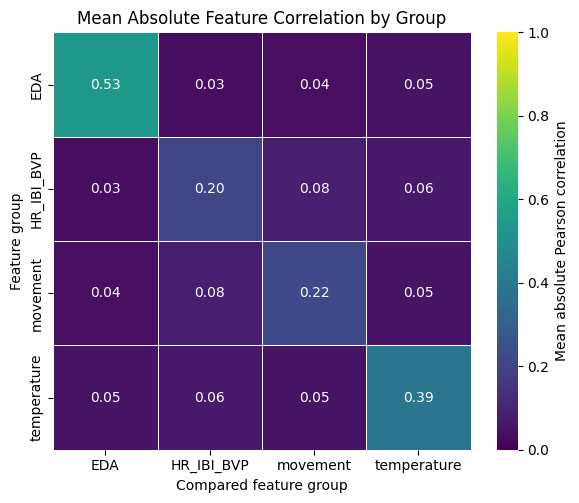

In [3]:
feature_columns = [
    column for column in train_df.columns if column not in FEATURE_ID_COLUMNS
]
X_train = train_df[feature_columns]
y_train = train_df["label"]
groups_train = train_df["participant_id"]

X_val = val_df[feature_columns]
y_val = val_df["label"]

feature_groups = feature_groups_from_columns(feature_columns)
feature_group_correlation = feature_group_correlation_matrix(X_train, feature_groups)
feature_group_correlation.to_csv(
    stage6_output_dir / "feature_group_correlation_matrix.csv"
)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    feature_group_correlation,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Mean absolute Pearson correlation"},
    ax=ax,
)
ax.set_xlabel("Compared feature group")
ax.set_ylabel("Feature group")
ax.set_title("Mean Absolute Feature Correlation by Group")
fig.tight_layout()
fig.savefig(
    stage6_output_dir / "feature_group_correlation_matrix.png",
    bbox_inches="tight",
    dpi=150,
)
display(fig)
plt.close(fig)

n_splits = min(5, groups_train.nunique())
if n_splits < 2:
    raise ValueError(
        "Participant-level cross-validation needs at least two training participants."
    )

cv = GroupKFold(n_splits=n_splits)
# Sample weights are used to balance the XGBoost training loss only; model
# selection and validation diagnostics intentionally use unweighted macro-F1.
def labeled_macro_f1_score(y_true, y_pred, sample_weight=None):
    return f1_score(
        y_true,
        y_pred,
        average="macro",
        labels=TARGET_SLEEP_STAGE_LABELS,
        zero_division=0,
    )

def unlabeled_macro_f1_score(y_true, y_pred, sample_weight=None):
    return f1_score(y_true, y_pred, average="macro", zero_division=0)

macro_f1 = make_scorer(labeled_macro_f1_score, response_method="predict")
macro_f1_unlabeled = make_scorer(unlabeled_macro_f1_score, response_method="predict")
metrics_rows = []
confusion_matrices = {}
feature_importances = {}
group_importances = {}

def record_validation_result(model_name, predictions):
    metrics, matrix = evaluate_predictions(
        y_val,
        predictions,
        model_name=model_name,
        split="validation",
    )
    metrics_rows.append(metrics)
    confusion_matrices[model_name] = matrix
    return metrics, matrix

## Majority Class Baseline

This sanity-check model always predicts the most frequent training label. It is fit on the training feature table and evaluated once on the validation feature table. The expected outputs are one validation metrics row and a labeled confusion matrix, which establish the minimum useful benchmark for later models.

In [4]:
majority_model = DummyClassifier(strategy="most_frequent")
majority_model.fit(X_train, y_train)
majority_predictions = majority_model.predict(X_val)
majority_metrics, majority_confusion = record_validation_result(
    "majority_class",
    majority_predictions,
)
display(pd.DataFrame([majority_metrics]))
display(majority_confusion)

,model,split,accuracy,balanced_accuracy,macro_f1,Wake_precision,Wake_recall,Wake_f1,Non_REM_precision,Non_REM_recall,Non_REM_f1,REM_precision,REM_recall,REM_f1
0,majority_class,validation,0.706411,0.333333,0.275983,0.0,0.0,0.0,0.706411,1.0,0.827949,0.0,0.0,0.0


,pred_Wake,pred_Non-REM,pred_REM
true_Wake,0,2110,0
true_Non-REM,0,8496,0
true_REM,0,1421,0


## Elastic-Net Multinomial Logistic Regression

This section fits a scikit-learn pipeline with median imputation, standardization, and balanced multinomial logistic regression using elastic-net regularization. `solver="saga"` supports the tuned `C` and `l1_ratio` settings; multiclass handling is left to scikit-learn's current default behavior for multinomial classification. `GridSearchCV` tunes on the training split only with participant-level cross-validation, then evaluates the selected pipeline once on validation. Expected outputs are the top CV settings, a validation metrics row, a confusion matrix, and feature-level plus group-level validation-set permutation importance.

In [5]:
logistic_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                solver="saga",
                class_weight="balanced",
                max_iter=10000,
                random_state=42,
            ),
        ),
    ]
)

logistic_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid={
        "model__C": [0.01, 0.1, 1.0, 10.0],
        "model__l1_ratio": [0.0, 0.5, 1.0],
    },
    scoring=macro_f1,
    cv=cv,
    n_jobs=-1,
    refit=True,
)
logistic_search.fit(X_train, y_train, groups=groups_train)
logistic_predictions = logistic_search.predict(X_val)
logistic_metrics, logistic_confusion = record_validation_result(
    "logistic_elasticnet",
    logistic_predictions,
)
logistic_importance = permutation_importance_frame(
    logistic_search.best_estimator_,
    X_val,
    y_val,
    scoring=macro_f1,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)
logistic_group_importance = grouped_permutation_importance_frame(
    logistic_search.best_estimator_,
    X_val,
    y_val,
    feature_groups,
    scoring=macro_f1,
    n_repeats=10,
    random_state=42,
)
feature_importances["logistic_elasticnet"] = logistic_importance
group_importances["logistic_elasticnet"] = logistic_group_importance

display(pd.DataFrame(logistic_search.cv_results_).sort_values("rank_test_score").head(10))
display(pd.DataFrame([logistic_metrics]))
display(logistic_confusion)
display(logistic_importance.head(30))
display(logistic_group_importance)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_model__l1_ratio,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
6,721.000941,184.779011,0.125495,0.048324,1.00,0.0,"{'model__C': 1.0, 'model__l1_ratio': 0.0}",0.424374,0.378161,0.435529,0.471330,0.439313,0.429741,0.030147,1
7,993.244908,237.051366,0.102591,0.011245,1.00,0.5,"{'model__C': 1.0, 'model__l1_ratio': 0.5}",0.424915,0.378517,0.434937,0.470972,0.439356,0.429739,0.029888,2
0,87.339080,14.030450,0.084056,0.020096,0.01,0.0,"{'model__C': 0.01, 'model__l1_ratio': 0.0}",0.427993,0.377447,0.431631,0.469839,0.441257,0.429633,0.029939,3
3,311.210242,65.122341,0.105044,0.023234,0.10,0.0,"{'model__C': 0.1, 'model__l1_ratio': 0.0}",0.425876,0.379028,0.434553,0.468906,0.439771,0.429627,0.029135,4
8,1033.263323,328.292860,0.110559,0.053358,1.00,1.0,"{'model__C': 1.0, 'model__l1_ratio': 1.0}",0.425296,0.379028,0.434243,0.470668,0.438879,0.429623,0.029565,5
4,416.153873,95.011639,0.087917,0.019820,0.10,0.5,"{'model__C': 0.1, 'model__l1_ratio': 0.5}",0.426177,0.377839,0.433765,0.468882,0.440663,0.429465,0.029576,6
5,494.127819,98.333146,0.097365,0.018636,0.10,1.0,"{'model__C': 0.1, 'model__l1_ratio': 1.0}",0.425430,0.379140,0.432201,0.470133,0.440100,0.429401,0.029405,7
11,812.101408,131.284162,0.049311,0.010239,10.00,1.0,"{'model__C': 10.0, 'model__l1_ratio': 1.0}",0.423669,0.377965,0.435210,0.471328,0.438757,0.429386,0.030191,8
9,898.342005,187.927619,0.095509,0.023944,10.00,0.0,"{'model__C': 10.0, 'model__l1_ratio': 0.0}",0.423655,0.377865,0.435188,0.471379,0.438669,0.429351,0.030234,9
10,1001.320540,160.091988,0.058040,0.013500,10.00,0.5,"{'model__C': 10.0, 'model__l1_ratio': 0.5}",0.423598,0.377832,0.435135,0.471450,0.438738,0.429351,0.030270,10


,model,split,accuracy,balanced_accuracy,macro_f1,Wake_precision,Wake_recall,Wake_f1,Non_REM_precision,Non_REM_recall,Non_REM_f1,REM_precision,REM_recall,REM_f1
0,logistic_elasticnet,validation,0.402095,0.470829,0.374741,0.316752,0.467773,0.377727,0.796929,0.354284,0.490508,0.16342,0.590429,0.255988


,pred_Wake,pred_Non-REM,pred_REM
true_Wake,987,442,681
true_Non-REM,1872,3010,3614
true_REM,257,325,839


,feature,importance_mean,importance_std
24,ACC_Z_mean,0.101667,0.003417
27,ACC_Z_max,0.094740,0.002776
18,ACC_Y_min,0.066799,0.001736
26,ACC_Z_min,0.054549,0.003350
28,ACC_Z_median,0.049274,0.002173
34,TEMP_min,0.047308,0.003496
19,ACC_Y_max,0.043889,0.001742
59,IBI_max,0.042568,0.002098
10,ACC_X_min,0.038619,0.002436
56,IBI_mean,0.029874,0.002050


,feature_group,n_features,baseline_score,importance_mean,importance_std
0,HR_IBI_BVP,24,0.374741,0.031908,0.002883
1,movement,32,0.374741,0.030605,0.003162
3,temperature,8,0.374741,0.015071,0.002796
2,EDA,8,0.374741,-0.000103,0.001591


## XGBoost Baseline

This section trains XGBoost on all engineered features when the package is installed. Labels are encoded for XGBoost, balanced sample weights are computed from the training labels, and a modest grid over tree depth, learning rate, sampling, and regularization is tuned with participant-level training CV only. The selected model is evaluated once on validation, then validation-set feature-level and group-level permutation importance are computed as diagnostics. Expected outputs are the top CV settings, validation metrics, a confusion matrix, and the most important features and feature groups by permutation importance.

In [6]:
if XGBClassifier is None:
    print("xgboost is not installed; install it to run the XGBoost baseline.")
    xgb_search = None
    xgb_importance = pd.DataFrame()
    xgb_group_importance = pd.DataFrame()
else:
    label_encoder = LabelEncoder()
    y_train_encoded = label_encoder.fit_transform(y_train)
    y_val_encoded = label_encoder.transform(y_val)
    xgb_sample_weight = balanced_sample_weights(y_train_encoded)

    xgb_model = XGBClassifier(
        objective="multi:softprob",
        num_class=len(label_encoder.classes_),
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=42,
    )
    xgb_search = GridSearchCV(
        estimator=xgb_model,
        param_grid={
            "max_depth": [2, 3, 4],
            "learning_rate": [0.03, 0.1],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0],
            "reg_lambda": [1.0, 5.0],
            "min_child_weight": [1, 5],
        },
        scoring=macro_f1_unlabeled,
        cv=cv,
        n_jobs=-1,
        refit=True,
    )
    xgb_search.fit(
        X_train,
        y_train_encoded,
        groups=groups_train,
        sample_weight=xgb_sample_weight,
    )
    xgb_predictions = label_encoder.inverse_transform(xgb_search.predict(X_val))
    xgb_metrics, xgb_confusion = record_validation_result(
        "xgboost_all_features",
        xgb_predictions,
    )

    xgb_importance = permutation_importance_frame(
        xgb_search.best_estimator_,
        X_val,
        y_val_encoded,
        scoring=macro_f1_unlabeled,
        n_repeats=10,
        random_state=42,
        n_jobs=-1,
    )
    xgb_group_importance = grouped_permutation_importance_frame(
        xgb_search.best_estimator_,
        X_val,
        y_val_encoded,
        feature_groups,
        scoring=macro_f1_unlabeled,
        n_repeats=10,
        random_state=42,
    )
    feature_importances["xgboost_all_features"] = xgb_importance
    group_importances["xgboost_all_features"] = xgb_group_importance

    display(pd.DataFrame(xgb_search.cv_results_).sort_values("rank_test_score").head(10))
    display(pd.DataFrame([xgb_metrics]))
    display(xgb_confusion)
    display(xgb_importance.head(30))
    display(xgb_group_importance)

/home/manns79/dreamt-wearable-sleep-staging/.venv/lib/python3.12/site-packages/sklearn/model_selection/_search.py:883: UserWarning: The scoring make_scorer(unlabeled_macro_f1_score, response_method='predict') does not support sample_weight, which may lead to statistically incorrect results when fitting GridSearchCV(cv=GroupKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_p...
                 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_colsample_bytree,param_learning_rate,param_max_depth,param_min_child_weight,param_reg_lambda,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
90,15.518342,1.183858,0.141273,0.026215,1.0,0.1,4,1,5.0,0.8,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",0.448232,0.418728,0.505380,0.500138,0.489963,0.472488,0.033557,1
88,16.279410,2.820495,0.179975,0.021587,1.0,0.1,4,1,1.0,0.8,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",0.452317,0.417283,0.496801,0.504220,0.490290,0.472182,0.032769,2
40,12.943083,0.481964,0.169480,0.046858,0.8,0.1,4,1,1.0,0.8,"{'colsample_bytree': 0.8, 'learning_rate': 0.1...",0.452290,0.423033,0.497162,0.500726,0.486680,0.471978,0.029867,3
84,10.446194,0.331210,0.129077,0.012679,1.0,0.1,3,5,1.0,0.8,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",0.463624,0.419559,0.490716,0.498625,0.482785,0.471062,0.028253,4
80,9.331707,0.594874,0.131020,0.016949,1.0,0.1,3,1,1.0,0.8,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",0.463938,0.415177,0.494489,0.495603,0.485668,0.470975,0.030127,5
86,11.786678,1.710143,0.189807,0.074527,1.0,0.1,3,5,5.0,0.8,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",0.464407,0.419437,0.493797,0.491324,0.485450,0.470883,0.027726,6
94,12.712433,1.156432,0.078696,0.021063,1.0,0.1,4,5,5.0,0.8,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",0.451074,0.415345,0.498443,0.503134,0.486366,0.470872,0.033215,7
91,14.756722,1.231419,0.175653,0.040119,1.0,0.1,4,1,5.0,1.0,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",0.451784,0.420016,0.499671,0.498888,0.482149,0.470501,0.030632,8
42,13.524690,1.185985,0.141273,0.010011,0.8,0.1,4,1,5.0,0.8,"{'colsample_bytree': 0.8, 'learning_rate': 0.1...",0.455097,0.417127,0.498701,0.495019,0.485729,0.470335,0.030706,9
89,17.178765,1.541328,0.196641,0.047890,1.0,0.1,4,1,1.0,1.0,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",0.447534,0.418069,0.498871,0.502833,0.482879,0.470037,0.032493,10


,model,split,accuracy,balanced_accuracy,macro_f1,Wake_precision,Wake_recall,Wake_f1,Non_REM_precision,Non_REM_recall,Non_REM_f1,REM_precision,REM_recall,REM_f1
0,xgboost_all_features,validation,0.476594,0.429716,0.383188,0.29205,0.58673,0.389983,0.75368,0.494115,0.5969,0.133454,0.208304,0.162682


,pred_Wake,pred_Non-REM,pred_REM
true_Wake,1238,563,309
true_Non-REM,2685,4198,1613
true_REM,316,809,296


,feature,importance_mean,importance_std
49,HR_std,1.230249e-02,1.709969e-03
25,ACC_Z_std,4.559842e-03,1.248842e-03
33,TEMP_std,4.424621e-03,1.222710e-03
9,ACC_X_std,4.015631e-03,1.080578e-03
46,EDA_slope,3.845854e-03,2.037682e-03
38,TEMP_slope,3.557222e-03,1.661541e-03
24,ACC_Z_mean,2.451698e-03,1.111760e-03
54,HR_slope,1.871981e-03,7.811707e-04
56,IBI_mean,1.475598e-03,7.764503e-04
14,ACC_X_slope,1.388835e-03,1.042825e-03


,feature_group,n_features,baseline_score,importance_mean,importance_std
1,movement,32,0.383188,0.027407,0.003515
0,HR_IBI_BVP,24,0.383188,0.024370,0.003413
3,temperature,8,0.383188,0.005228,0.002521
2,EDA,8,0.383188,0.001776,0.002125


## Interim Validation Summary

This final section combines validation metrics from the baselines, saves Stage 6 artifacts under `results/stage6_feature_baselines/`, and displays each confusion matrix. It saves validation confusion matrices for logistic regression and XGBoost as both CSV and PNG files, and writes feature-level plus group-level validation-set permutation importance for each model. These outputs are interim validation diagnostics, not final test-set comparisons.

In [7]:
metrics_df = pd.DataFrame(metrics_rows)
display(metrics_df.sort_values("macro_f1", ascending=False))

metrics_output_path = stage6_output_dir / "validation_metrics.csv"
metrics_df.to_csv(metrics_output_path, index=False)
print(f"Saved validation metrics to {metrics_output_path}")

saved_confusion_models = {"logistic_elasticnet", "xgboost_all_features"}
for model_name, matrix in confusion_matrices.items():
    display(model_name)
    display(matrix)
    if model_name in saved_confusion_models:
        matrix.to_csv(
            stage6_output_dir / f"validation_confusion_matrix_{model_name}.csv"
        )
        plot_confusion_matrix(
            matrix,
            stage6_output_dir / f"validation_confusion_matrix_{model_name}.png",
        )

for model_name, importance in feature_importances.items():
    importance_output_path = (
        stage6_output_dir / f"validation_permutation_importance_{model_name}.csv"
    )
    importance.to_csv(importance_output_path, index=False)
    print(f"Saved feature-level permutation importance to {importance_output_path}")

for model_name, importance in group_importances.items():
    importance_output_path = (
        stage6_output_dir
        / f"validation_group_permutation_importance_{model_name}.csv"
    )
    importance.to_csv(importance_output_path, index=False)
    print(f"Saved group-level permutation importance to {importance_output_path}")

,model,split,accuracy,balanced_accuracy,macro_f1,Wake_precision,Wake_recall,Wake_f1,Non_REM_precision,Non_REM_recall,Non_REM_f1,REM_precision,REM_recall,REM_f1
2,xgboost_all_features,validation,0.476594,0.429716,0.383188,0.292050,0.586730,0.389983,0.753680,0.494115,0.596900,0.133454,0.208304,0.162682
1,logistic_elasticnet,validation,0.402095,0.470829,0.374741,0.316752,0.467773,0.377727,0.796929,0.354284,0.490508,0.163420,0.590429,0.255988
0,majority_class,validation,0.706411,0.333333,0.275983,0.000000,0.000000,0.000000,0.706411,1.000000,0.827949,0.000000,0.000000,0.000000


Saved validation metrics to /home/manns79/dreamt-wearable-sleep-staging/results/stage6_feature_baselines/validation_metrics.csv


'majority_class'

,pred_Wake,pred_Non-REM,pred_REM
true_Wake,0,2110,0
true_Non-REM,0,8496,0
true_REM,0,1421,0


'logistic_elasticnet'

,pred_Wake,pred_Non-REM,pred_REM
true_Wake,987,442,681
true_Non-REM,1872,3010,3614
true_REM,257,325,839


'xgboost_all_features'

,pred_Wake,pred_Non-REM,pred_REM
true_Wake,1238,563,309
true_Non-REM,2685,4198,1613
true_REM,316,809,296


Saved feature-level permutation importance to /home/manns79/dreamt-wearable-sleep-staging/results/stage6_feature_baselines/validation_permutation_importance_logistic_elasticnet.csv
Saved feature-level permutation importance to /home/manns79/dreamt-wearable-sleep-staging/results/stage6_feature_baselines/validation_permutation_importance_xgboost_all_features.csv
Saved group-level permutation importance to /home/manns79/dreamt-wearable-sleep-staging/results/stage6_feature_baselines/validation_group_permutation_importance_logistic_elasticnet.csv
Saved group-level permutation importance to /home/manns79/dreamt-wearable-sleep-staging/results/stage6_feature_baselines/validation_group_permutation_importance_xgboost_all_features.csv
